In [1]:
import results_deser as rd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Pixel-shuffling

This notebook produces tables and graphs provided in Section 5 of the report.

## CIFAR10

Results for simple pixel shuffling:

In [2]:
accs = [rd.load_testaccs("results/r_cf10_rn18_pshuffleonly_" + str(i)) for i in range(4)]
df_s10 = pd.DataFrame(accs)
df_s10.loc["mean"] = df_s10.mean(axis=0)
df_s10

,[1.]
0,55.3800
1,56.0500
2,56.3200
3,56.1400
mean,55.9725


Benchmark mean:

In [3]:
85.17

85.17

## CIFAR100

In [4]:
accs = [rd.load_testaccs("results/r_cf100_rn18_pshuffleonly_" + str(i)) for i in range(4)]
df_s100 = pd.DataFrame(accs)
df_s100.loc["mean"] = df_s100.mean(axis=0)
df_s100

,[1.]
0,27.00
1,27.35
2,27.42
3,27.47
mean,27.31


Benchmark mean:

In [5]:
54.83

54.83

In [6]:
df_all = df_s10.copy()
df_all[0] = df_s100
df_all.columns = ["CIFAR10", "CIFAR100"]

df_all

,CIFAR10,CIFAR100
0,55.3800,27.00
1,56.0500,27.35
2,56.3200,27.42
3,56.1400,27.47
mean,55.9725,27.31


In [7]:
print(df_all.to_latex())

\begin{tabular}{lrr}
\toprule
{} &  CIFAR10 &  CIFAR100 \\
\midrule
0    &  55.3800 &     27.00 \\
1    &  56.0500 &     27.35 \\
2    &  56.3200 &     27.42 \\
3    &  56.1400 &     27.47 \\
mean &  55.9725 &     27.31 \\
\bottomrule
\end{tabular}



## Shuffle+Mixup, maxobf

In [8]:
accs = [rd.load_testaccs("results/r_cf10_rn18_n"+str(i)+"_pshuffle_mixup_maxobf") for i in range(2, 6)]
df1 = pd.DataFrame(accs)
df1 = pd.DataFrame(np.diag(df1).reshape(1, 4), index=["maxobf cifar10"], columns=range(2, 6))

df1

,2,3,4,5
maxobf cifar10,55.91,55.15,51.21,48.04


In [9]:
accs = [rd.load_testaccs("results/r_cf10_rn18_n"+str(i)+"_pshuffle_mixup_sweetspot") for i in range(2, 6)]
df2 = pd.DataFrame(accs)
df2 = pd.DataFrame(np.diag(df2).reshape(1, 4), index=["sweetspot cifar10"], columns=range(2, 6))
df2

,2,3,4,5
sweetspot cifar10,57.68,56.22,56.67,55.73


In [10]:
accs = [rd.load_testaccs("results/r_cf100_rn18_n"+str(i)+"_pshuffle_mixup_maxobf") for i in range(2, 6)]
df3 = pd.DataFrame(accs)
df3 = pd.DataFrame(np.diag(df3).reshape(1, 4), index=["maxobf cifar100"], columns=range(2, 6))
df3

,2,3,4,5
maxobf cifar100,29.46,25.95,25.85,22.49


In [11]:
accs = [rd.load_testaccs("results/r_cf100_rn18_n"+str(i)+"_pshuffle_mixup_sweetspot") for i in range(2, 6)]
df4 = pd.DataFrame(accs)
df4 = pd.DataFrame(np.diag(df4).reshape(1, 4), index=["sweetspot cifar100"], columns=range(2, 6))
df4

,2,3,4,5
sweetspot cifar100,29.54,28.75,29.44,28.56


In [12]:
df_all = pd.concat([df1, df2, df3, df4])

In [13]:
df_all

,2,3,4,5
maxobf cifar10,55.91,55.15,51.21,48.04
sweetspot cifar10,57.68,56.22,56.67,55.73
maxobf cifar100,29.46,25.95,25.85,22.49
sweetspot cifar100,29.54,28.75,29.44,28.56


In [14]:
print(df_all.to_latex())

\begin{tabular}{lrrrr}
\toprule
{} &      2 &      3 &      4 &      5 \\
\midrule
maxobf cifar10     &  55.91 &  55.15 &  51.21 &  48.04 \\
sweetspot cifar10  &  57.68 &  56.22 &  56.67 &  55.73 \\
maxobf cifar100    &  29.46 &  25.95 &  25.85 &  22.49 \\
sweetspot cifar100 &  29.54 &  28.75 &  29.44 &  28.56 \\
\bottomrule
\end{tabular}



In [15]:
df_s10.loc["mean"].values

array([55.9725])

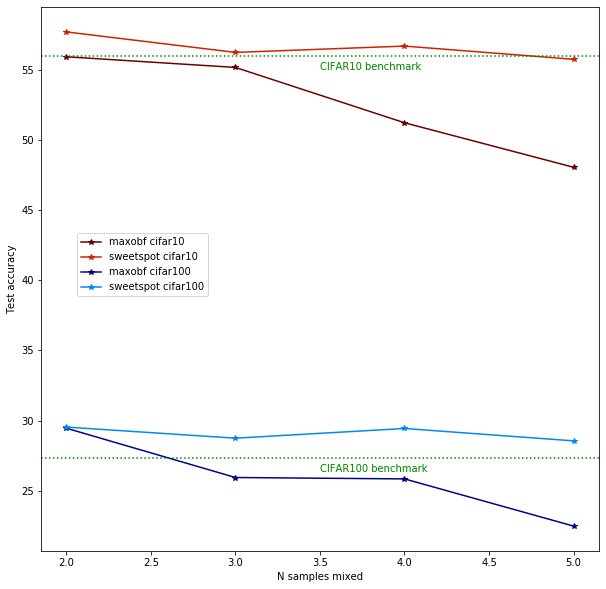

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))
COLORS = ["#670000", "#cd2200", "#000088", "#0088ee"]
j = 0
for i, v in df_all.iterrows():
    ax.plot(v, label=v.name, color=COLORS[j], marker="*")
    j+=1

ax.axhline(y=df_s10.loc["mean"].values, linestyle="dotted", color="green")
ax.axhline(y=df_s100.loc["mean"].values, linestyle="dotted", color="green")
ax.text(x=3.5, y=df_s10.loc["mean"]-1, s="CIFAR10 benchmark", color="green")
ax.text(x=3.5, y=df_s100.loc["mean"]-1, s="CIFAR100 benchmark", color="green")
ax.set_xlabel("N samples mixed")
ax.set_ylabel("Test accuracy")
fig.legend(loc="lower left", bbox_to_anchor=(.1, .4))
fig.savefig("pixel_shuffling.pdf")